# Late-time modelling

## Load the simulations

In [ ]:
from ipynb_boilerplate import *
from crocodil.theory.system_a.late import LateTimeModel

PARAM_KEYS = ('Ra', 'Da')
PARAMS_FIXED = SYSTEM_A_REFERENCE.replace(sr=0.2).remove(*PARAM_KEYS)

simulations_batch = GridSimulationFromNPZ.dict_from_dir_paths(
    PARAM_KEYS, 
    SIM_DIR_PATHS,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_FIXED,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)
save_fig = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='late', 
    pickle=True,
    file_ext=('svg', 'png'),
)

In [ ]:
print('Before parameter selection')
for i in SIM_DIR_PATHS: print(i)
print('After parameter selection')
for i in simulations_batch.values(): print(i.dir_path)

## Select the simulations

In [ ]:
Ra_targets = (500.0, 1000.0, 2000.0)
Da_targets = (1.0, 10.0, 100.0, 1000.0)
include = lambda prm, trgs: prm in trgs if trgs else True
simulations = {
    (Ra, Da): v for (Ra, Da), v in simulations_batch.items()
    if include(Ra, Ra_targets) and include(Da, Da_targets)
}

## Comparison of model with DNS

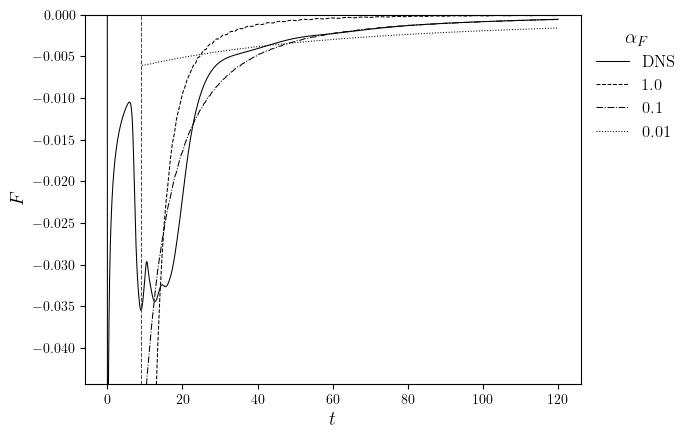

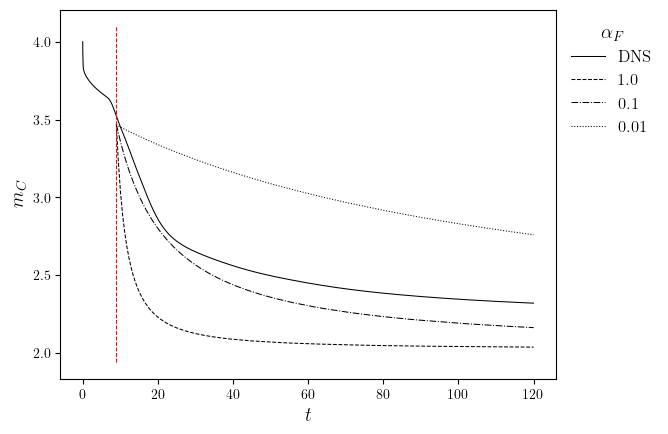

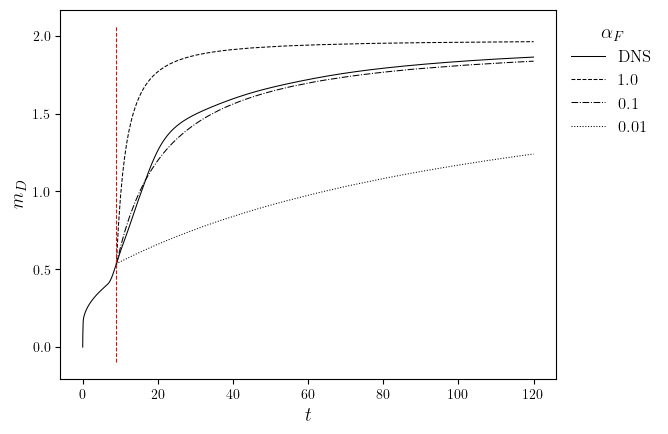

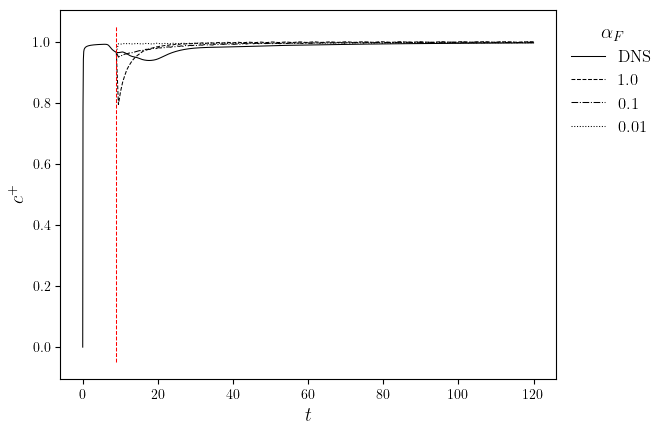

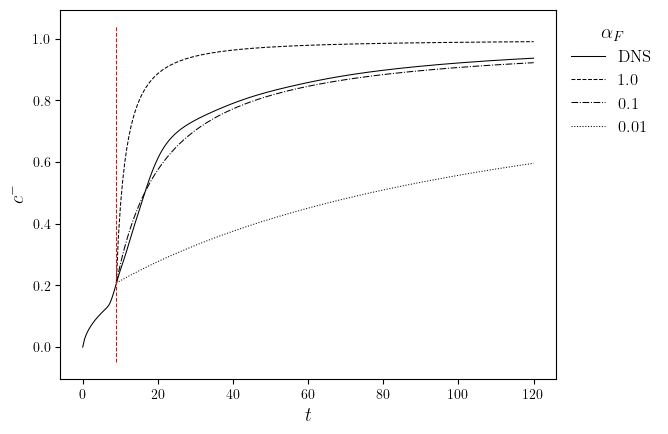

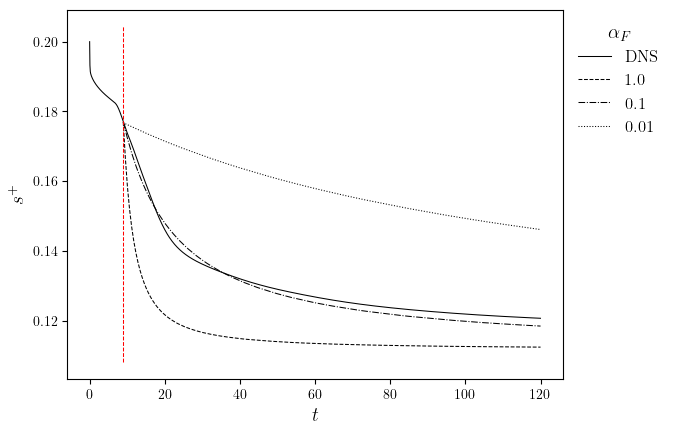

: 

In [ ]:
from ipynb_utils import when_geq_first

uRMS_onset = 1e-3
time_max = 120.0

alpha_cs = 0.5
alpha_f_opts = (1.0, 0.1, 0.01)
ics_opt = 'peak'

for (Ra, Da), sim in simulations.items():

    if not (Ra, Da) == (500.0, 100.0):
        continue

    epsilon, zeta0, sr, cr, aspect = sim['epsilon', 'zeta0', 'sr', 'cr', 'aspect']
    s, c, mC, mD, f, uRMS = sim['s', 'c', 'mC', 'mD', 'f', 'uRMS']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    zeta0_index = as_index(c.mesh.y_axis, zeta0)
    slcPlus = slice(zeta0_index, None)
    slcMinus = slice(0, zeta0_index)
    cPlus = NPyConstantSeries(
        average_grid(c.series, ('x', 'y'), (':', slcPlus)), c.time_series, 'cPlus',
    )
    cMinus = NPyConstantSeries(
        average_grid(c.series, ('x', 'y'), (':', slcMinus)), c.time_series, 'cMinus',
    )
    sPlus = NPyConstantSeries(
        average_grid(s.series, ('x', 'y'), (':', slcPlus)), s.time_series, 'sPlus',
    )
    legend_labels = ['DNS']
    legend_title = '$\\alpha_F$'
    f_lines = [(fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series])]
    mC_lines = [(mC.time_series, mC.value_series)]
    mD_lines = [(mD.time_series, mD.value_series)]
    cPlus_lines = [(cPlus.time_series, cPlus.value_series)]
    cMinus_lines = [(cMinus.time_series, cMinus.value_series)]
    sPlus_lines = [(sPlus.time_series, sPlus.value_series)]

    if ics_opt in ('onset', 'peak'):
        tOnset = when_geq_first(uRMS.value_series, uRMS.time_series, uRMS_onset)
        if ics_opt == 'peak':
            fZeta0Post_time_series = [t for t in fZeta0.time_series if t >= tOnset]
            fZeta0Post_value_series = [
                -np.sum(f) for t, f in zip(fZeta0.time_series, fZeta0.value_series) if t >= tOnset
            ]
            fPeak = np.max(fZeta0Post_value_series)
            tPeak = when_geq_first(fZeta0Post_value_series, fZeta0Post_time_series, fPeak)
            t_ics = tPeak
        else:
            t_ics = tOnset
    else:
        raise ValueError(f'{ics_opt} not recognised.')

    ics = (
        cPlus.value_series[as_index(cPlus.time_series, t_ics)],
        cMinus.value_series[as_index(cMinus.time_series, t_ics)],
        sPlus.value_series[as_index(sPlus.time_series, t_ics)],
    )
    for alpha_f in alpha_f_opts:
        late_model = LateTimeModel(
            np.linspace(t_ics, time_max, num=200),
            aspect * 1,
            Da,
            epsilon,
            zeta0,
            sr,
            cr,
            alpha_cs,
            lambda cp, cm: alpha_f * (cp - cm)**2,
            constraint=None,
            ics=ics,
        )
        f_lines.append((late_model.t, -late_model.f))
        mC_lines.append((late_model.t, late_model.mC))
        mD_lines.append((late_model.t, late_model.mD))
        cPlus_lines.append((late_model.t, late_model.cPlus))
        cMinus_lines.append((late_model.t, late_model.cMinus))
        sPlus_lines.append((late_model.t, late_model.sPlus))
        legend_labels.append(alpha_f)

    add_start_line = lambda ax:(
        ax.vlines(
            t_ics, 
            *ax.get_ylim(), 
            linewidths=0.75, 
            linestyles='dashed', 
            colors='red',
        )
    )
    kws = dict(
        x_label='$t$',
        legend_labels=legend_labels,
        legend_title=legend_title,
    )
    fig, ax = plot_line(
        f_lines,
        y_label='$F$',
        y_lims=(-1.25 * fPeak, 0),
        **kws,
    )
    add_start_line(ax)

    fig, ax = plot_line(
        mC_lines,
        y_label='$m_C$',
        **kws,
    )
    add_start_line(ax)

    fig, ax = plot_line(
        mD_lines,
        y_label='$m_D$',
        **kws,
    )
    add_start_line(ax)

    fig, ax = plot_line(
        cPlus_lines,
        y_label='$c^+$',
        **kws,
    )
    add_start_line(ax)

    fig, ax = plot_line(
        cMinus_lines,
        y_label='$c^-$',
        **kws,
    )
    add_start_line(ax)

    fig, ax = plot_line(
        sPlus_lines,
        y_label='$s^+$',
        **kws,
    )
    add_start_line(ax)

